In [1]:
import glob
import pandas as pd
import numpy as np
import sys
import os
from PIL import Image
import cv2
import json
import matplotlib.pyplot as plt

sys.path.append("../../../../donut/src/test/")
from common.config import cfg

import warnings

warnings.filterwarnings("ignore")

/var/folders/5b/b2jjkdb55_g_qzx3lsl5k59m0000gn/T/ipykernel_56471/448637386.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
os.getcwd()

'/Users/yiding/personal_projects/ML/github_repo/donut/src/test/preprocess'

In [4]:
# list all image paths
image_dir = "../../../data/raw/train/images/"
image_files = glob.glob(image_dir + "*")
print(len(image_files))
print(image_files[:5])

60578
['../../../data/raw/train/images/45df1fe3293b.jpg', '../../../data/raw/train/images/b2ab3b743d4e.jpg', '../../../data/raw/train/images/51d3b1a6baf3.jpg', '../../../data/raw/train/images/a9e9ce9277c1.jpg', '../../../data/raw/train/images/7f1f545fe081.jpg']


In [5]:
# list all annotation files paths

annotations_dir="../../../data/raw/train/annotations/"
annotations_files=glob.glob(annotations_dir+"*")
print(len(annotations_files))
print(annotations_files[:5])

60578
['../../../data/raw/train/annotations/e91e28111e86.json', '../../../data/raw/train/annotations/75c0449f6917.json', '../../../data/raw/train/annotations/66dd2a250237.json', '../../../data/raw/train/annotations/58595c30beab.json', '../../../data/raw/train/annotations/497a547454d7.json']


In [6]:
# filter out the path including typical characters

# line image
search_string = "0a0a78fc8d65"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0a0a78fc8d65.jpg']
['../../../data/raw/train/annotations/0a0a78fc8d65.json']


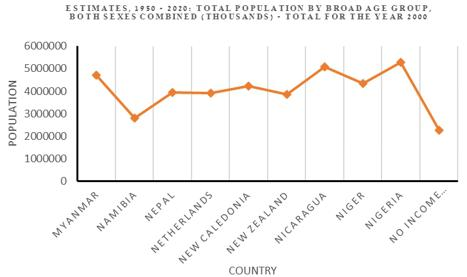

In [7]:
Image.open(fp=matched_image_path[0])

(277, 467, 3)
<class 'numpy.ndarray'>


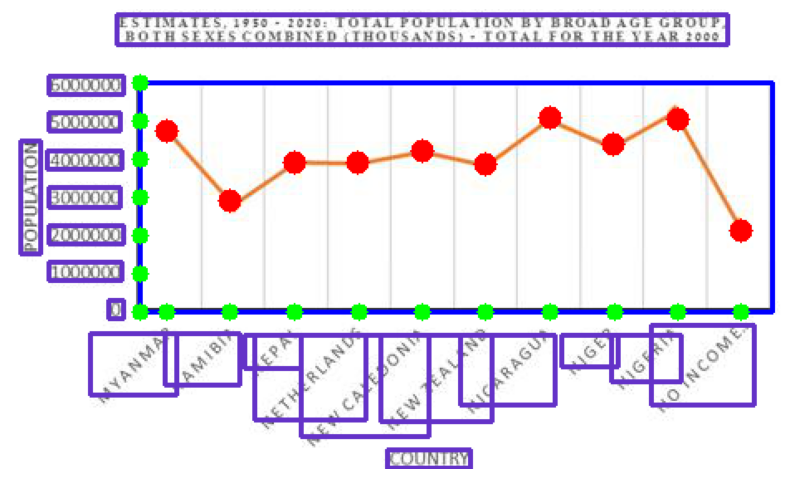

In [8]:
annotation_path = matched_annotation_path[0]
image_path = matched_image_path[0]

with open(annotation_path, "r") as f:
    annotation = json.load(f)

# load image
image = cv2.imread(image_path)
print(image.shape)
print(type(image))

# mark plot-bb (main body of the image) 
# use blue frame to display

# get the vertex to determine the boundary
plot_bb = annotation["plot-bb"]
x0, y0, width, height = plot_bb["x0"], plot_bb["y0"], plot_bb["width"], plot_bb["height"]
cv2.rectangle(image, (x0, y0), (x0 + width, y0 + height), (255, 0, 0), 2) #(image, start point, end point, color, thickness)

# mark tick location on x or y axes
# use green dot to represent
for axis in ["x-axis", "y-axis"]:
    for tick in annotation["axes"].get(axis, {}).get("ticks", []):
        tick_x, tick_y = tick["tick_pt"]["x"], tick["tick_pt"]["y"]
        cv2.circle(image, (tick_x, tick_y), 5, (0, 255, 0), -1) 
        # cv2.putText(image, f"{tick_x},{tick_y}", (tick_x + 5, tick_y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# mark the points location on line graph
# use red dot to represent
for series in annotation["data-series"]:
    country = series["x"]
    for data_point in annotation["visual-elements"]["lines"][0]: 
        x, y = int(data_point["x"]), int(data_point["y"])
        cv2.circle(image, (x, y), 7, (0, 0, 255), -1) 
        # cv2.putText(image, country, (x + 5, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

# mark the text region
# use purple frame to represent
for text_item in annotation["text"]:
    polygon = text_item["polygon"]
    x0, y0, x1, y1 = polygon["x0"], polygon["y0"], polygon["x1"], polygon["y1"]
    x2, y2, x3, y3 = polygon["x2"], polygon["y2"], polygon["x3"], polygon["y3"]

    cv2.rectangle(image, (x0, y0), (x2, y2), (200, 50, 100), 2) 

    # text_label = text_item["text"][:15] + "..." if len(text_item["text"]) > 15 else text_item["text"]
    # cv2.putText(image, text_label, (x0, y0 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 165, 0), 1)

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [9]:
type(image)

numpy.ndarray

In [10]:
# def image_markable(annotation_path:str,image_path:str)-> np.array:
#     '''
#     mark all the information mentioned in the annotation.json on the corresponding image file
#     Params:
#         annotation_path: the path fo annotation file
#         image_path: the path of the image file

#     return: numpy.ndarray
#     '''

#     with open(annotation_path, "r") as f:
#         annotation = json.load(f)

#     # load image
#     image = cv2.imread(image_path)
#     print(image.shape)
#     print(type(image))

#     # mark plot-bb (main body of the image) 
#     # use blue frame to display

#     # get the vertex to determine the boundary
#     plot_bb = annotation["plot-bb"]
#     x0, y0, width, height = plot_bb["x0"], plot_bb["y0"], plot_bb["width"], plot_bb["height"]
#     cv2.rectangle(image, (x0, y0), (x0 + width, y0 + height), (255, 0, 0), 2) #(image, start point, end point, color, thickness)

#     # mark tick location on x or y axes
#     # use green dot to represent
#     for axis in ["x-axis", "y-axis"]:
#         for tick in annotation["axes"].get(axis, {}).get("ticks", []):
#             tick_x, tick_y = tick["tick_pt"]["x"], tick["tick_pt"]["y"]
#             cv2.circle(image, (tick_x, tick_y), 5, (0, 255, 0), -1) 
#             # cv2.putText(image, f"{tick_x},{tick_y}", (tick_x + 5, tick_y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

#     # mark the points location on line graph
#     # use red dot to represent
#     for series in annotation["data-series"]:
#         country = series["x"]
#         for data_point in annotation["visual-elements"]["lines"][0]: 
#             x, y = int(data_point["x"]), int(data_point["y"])
#             cv2.circle(image, (x, y), 7, (0, 0, 255), -1) 
#             # cv2.putText(image, country, (x + 5, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

#     # mark the text region
#     # use purple frame to represent
#     for text_item in annotation["text"]:
#         polygon = text_item["polygon"]
#         x0, y0, x1, y1 = polygon["x0"], polygon["y0"], polygon["x1"], polygon["y1"]
#         x2, y2, x3, y3 = polygon["x2"], polygon["y2"], polygon["x3"], polygon["y3"]

#         cv2.rectangle(image, (x0, y0), (x2, y2), (200, 50, 100), 2) 

#         # text_label = text_item["text"][:15] + "..." if len(text_item["text"]) > 15 else text_item["text"]
#         # cv2.putText(image, text_label, (x0, y0 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 165, 0), 1)

#     return image

In [11]:
import cv2
import json
import numpy as np

def image_markable(annotation_path: str, image_path: str) -> np.array:
    '''
    Mark all the available information in the annotation.json on the corresponding image file.

    Params:
        annotation_path: the path of annotation file
        image_path: the path of the image file

    Return:
        numpy.ndarray (image with annotations)
    '''
    with open(annotation_path, "r") as f:
        annotation = json.load(f)

    # load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Error: Unable to load image at {image_path}")
        return None

    print(f"✅ Image loaded: {image.shape}")

    # missing elements in annotation file
    missing_elements = []

    # ----------------------  mark main body of the image (plot-bb) ----------------------
    plot_bb = annotation.get("plot-bb")
    if plot_bb:
        # get the vertex to determine the boundary
        x0, y0, width, height = plot_bb["x0"], plot_bb["y0"], plot_bb["width"], plot_bb["height"]
        cv2.rectangle(image, (x0, y0), (x0 + width, y0 + height), (255, 0, 0), 2)
    else:
        missing_elements.append("plot-bb")

    # ----------------------  mark tick location on x or y axes (ticks) ----------------------
    # use green dot to represent
    if "axes" in annotation:
        for axis in ["x-axis", "y-axis"]:
            if axis in annotation["axes"]:
                for tick in annotation["axes"][axis].get("ticks", []):
                    tick_x, tick_y = tick["tick_pt"]["x"], tick["tick_pt"]["y"]
                    cv2.circle(image, (tick_x, tick_y), 5, (0, 255, 0), -1)
            else:
                missing_elements.append(f"{axis} ticks")
    else:
        missing_elements.append("axes")

    # ----------------------  mark the points location on line graph (data-series) ----------------------
    if "visual-elements" in annotation:
        elements = annotation["visual-elements"]

        # `lines` 
        # red dot
        if "lines" in elements and elements["lines"]:
            for line in elements["lines"]:
                for data_point in line:
                    x, y = int(data_point["x"]), int(data_point["y"])
                    cv2.circle(image, (x, y), 7, (0, 0, 255), -1) 

        # `scatter points` 
        # light blue
        if "scatter points" in elements and elements["scatter points"]:
            for scatter in elements["scatter points"]:
                for point in scatter:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 0), -1) 

        # `bars`
        # light yellow
        if "bars" in elements and elements["bars"]:
            for bar in elements["bars"]:
                x0, y0 = int(bar["x0"]), int(bar["y0"])  
                width, height = int(bar["width"]), int(bar["height"])
                x1, y1 = x0 + width, y0 + height  
                cv2.rectangle(image, (x0, y0), (x1, y1), (0, 255, 255), -1) 

        # `boxplots`
        if "boxplots" in elements and elements["boxplots"]:
            for box in elements["boxplots"]:
                x, y = int(box["x"]), int(box["y"])
                cv2.rectangle(image, (x - 5, y - 5), (x + 5, y + 5), (255, 0, 255), 2) 

        if "dot points" in elements and elements["dot points"]:
            for dot in elements["dot points"]:
                for point in dot:
                    x, y = int(point["x"]), int(point["y"])
                    cv2.circle(image, (x, y), 6, (255, 165, 50), -1) 
    else:
        missing_elements.append("visual-elements")

    # ----------------------  `data-series` ----------------------
    if "data-series" in annotation:
        for series in annotation["data-series"]:
            x_value = series.get("x", "Unknown")
            y_value = series.get("y", "Unknown")
            # print(f"Data point: {x_value} -> {y_value}")
    else:
        missing_elements.append("data-series")

    # ---------------------- mark the text region (text) ----------------------
    # use purple frame to represent
    if "text" in annotation:
        for text_item in annotation["text"]:
            polygon = text_item.get("polygon")
            if polygon:
                x0, y0 = polygon["x0"], polygon["y0"]
                x2, y2 = polygon["x2"], polygon["y2"]
                cv2.rectangle(image, (x0, y0), (x2, y2), (200, 50, 100), 2)
            else:
                missing_elements.append(f"text id {text_item.get('id', 'unknown')} missing polygon")
    else:
        missing_elements.append("text")

    # ---------------------- 5️⃣ output missing elements ----------------------
    if missing_elements:
        print("⚠️ Missing elements in annotation:", ", ".join(set(missing_elements)))

    return image

✅ Image loaded: (277, 467, 3)


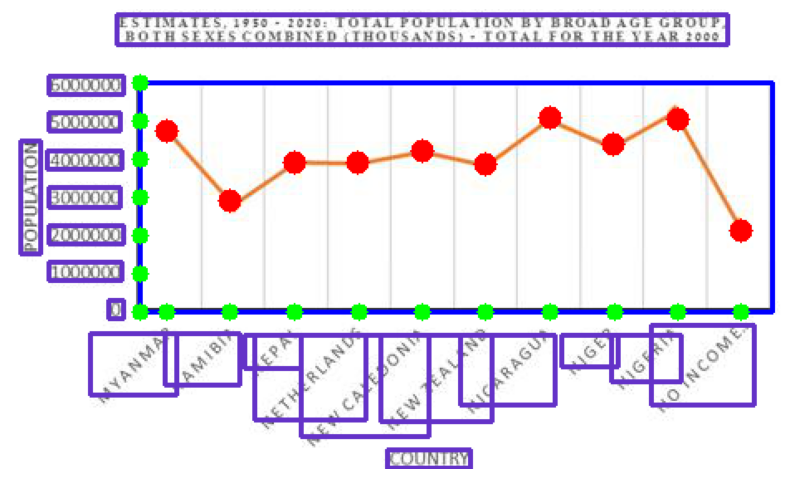

In [12]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [13]:
# filter out the path including typical characters

# scatter plot
search_string = "0a0ef43669cd"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0a0ef43669cd.jpg']
['../../../data/raw/train/annotations/0a0ef43669cd.json']


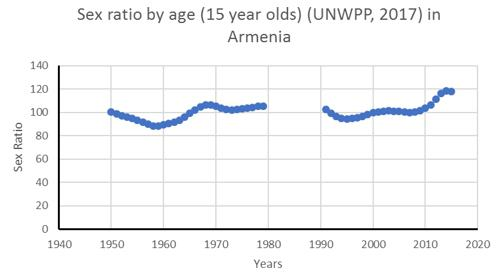

In [14]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (272, 498, 3)


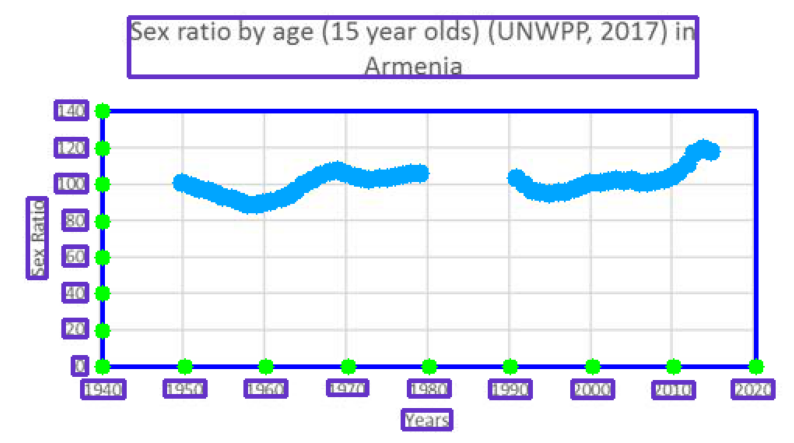

In [15]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [16]:
# filter out the path including typical characters

# vertical bar
search_string = "0b4dac8d0a28"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0b4dac8d0a28.jpg']
['../../../data/raw/train/annotations/0b4dac8d0a28.json']


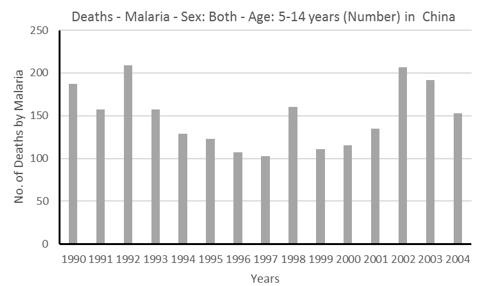

In [17]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (286, 481, 3)


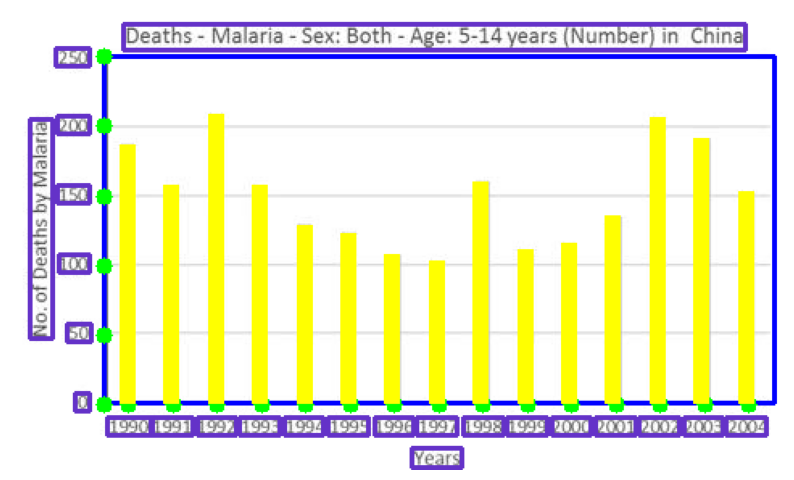

In [18]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [19]:
# filter out the path including typical characters

# dot
search_string = "0cfa6023c813"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/0cfa6023c813.jpg']
['../../../data/raw/train/annotations/0cfa6023c813.json']


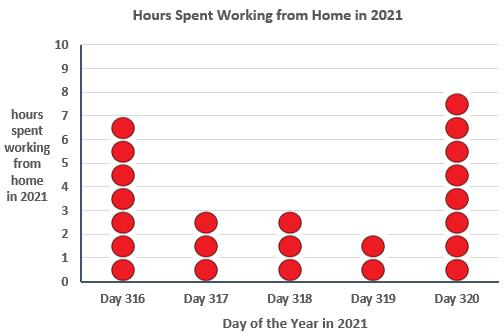

In [20]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (336, 504, 3)


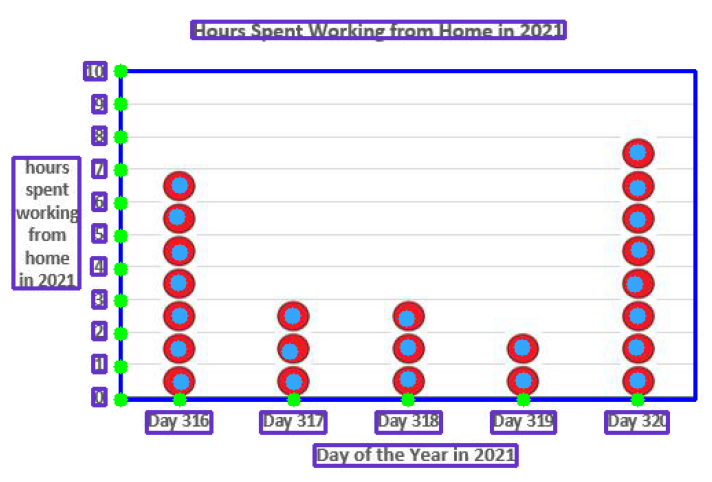

In [21]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [22]:
# filter out the path including typical characters

# horizontal bar
search_string = "1bd8fa4655f0"
matched_image_path = [file for file in image_files if search_string in file]

print(matched_image_path)

# corresponding annotation file path
matched_annotation_path = [file for file in annotations_files if search_string in file]

print(matched_annotation_path)

['../../../data/raw/train/images/1bd8fa4655f0.jpg']
['../../../data/raw/train/annotations/1bd8fa4655f0.json']


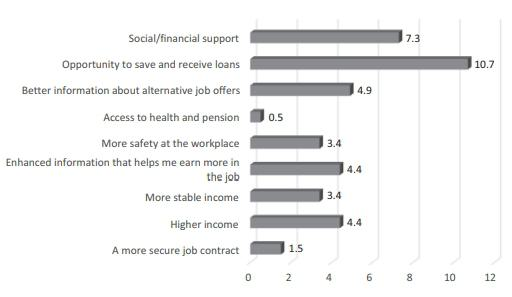

In [23]:
Image.open(fp=matched_image_path[0])

✅ Image loaded: (297, 512, 3)


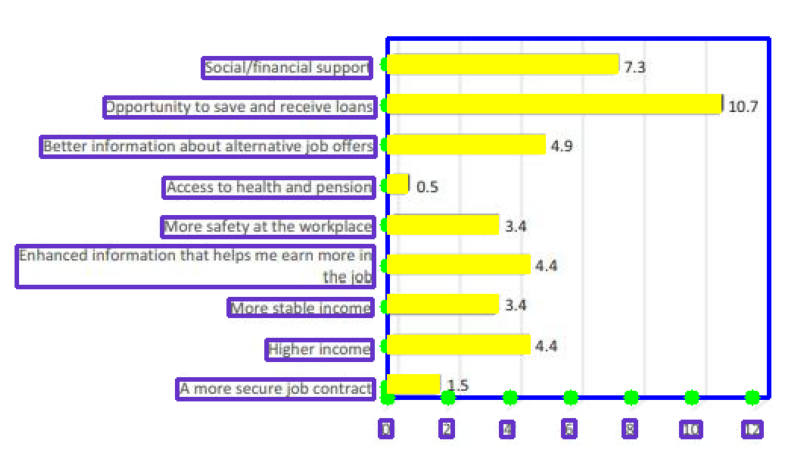

In [24]:
image=image_markable(annotation_path=matched_annotation_path[0],image_path=matched_image_path[0])

# show the image
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

#### annotation file insights

In [25]:
# here i would count the values in each annotation files, based off each plot type.

# check the total plot types
types_cnt={}
for annotations_path in annotations_files:
    with open(annotations_path, "r") as f:
        annotation = json.load(f)
    
    # print(f"{annotations_path}: {annotation['chart-type']}")

    # extract chart type
    chart_type=annotation['chart-type']
    # chart_type = annotation.get('chart-type', None)
    if chart_type not in types_cnt.keys():
        types_cnt[chart_type]=1
    else:
        types_cnt[chart_type]+=1

In [27]:
types_cnt

{'scatter': 11243,
 'vertical_bar': 19189,
 'dot': 5131,
 'line': 24942,
 'horizontal_bar': 73}

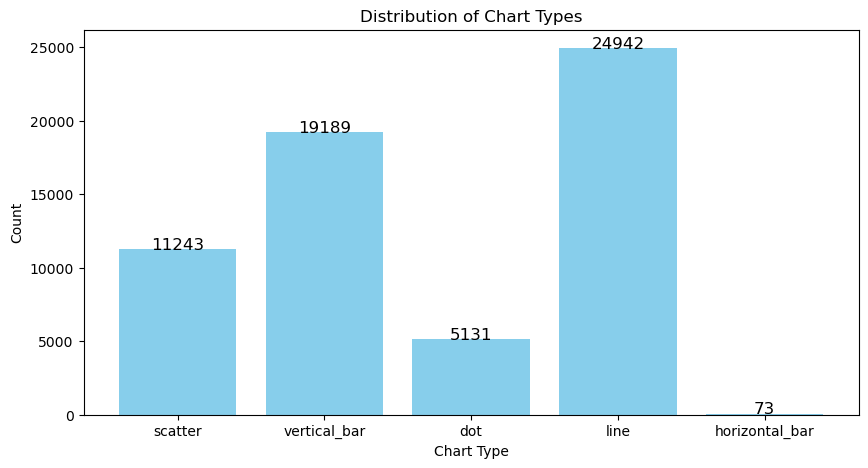

In [32]:
plt.figure(figsize=(10,5))

plt.bar(types_cnt.keys(), types_cnt.values(), color='skyblue')

plt.xlabel('Chart Type')
plt.ylabel('Count')
plt.title('Distribution of Chart Types')

for i, v in enumerate(types_cnt.values()):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=12)

plt.show()

In [40]:
# The visual-elements.data-series is equal to ground truth
# here I want to check the value types for each type of plot

# check if only keys (x,y) in the data-series

keys_outside_xy=[]

for annotations_path in annotations_files:
    with open(annotations_path, "r") as f:
        annotation = json.load(f)

    gt=annotation["data-series"]

    # check each ground truth's architecture
    all_valid=all(set(item.keys())=={"x","y"} for item in gt)

    while all_valid is False:
        keys_outside_xy.append(annotation_path)

# all gt has the some keys in all files
if len(keys_outside_xy)==0:
    print("all annotation ground truths have the same architecture")
else:
    print(keys_outside_xy)
    

all annotation ground truths have the same architecture


In [59]:
# gt_types_cnt={each_type:{axes:{} for axes in ["x","y"]} for each_type in types_cnt }

# gt_types_cnt

In [57]:
# check the value's type in ground truth (data-series)

gt_types_cnt={each_type:{axes:{} for axes in ["x","y"]} for each_type in types_cnt }

# store all annotation paths which including mutil types of values
multi_types_paths=[]

for annotations_path in annotations_files:
    with open(annotations_path, "r") as f:
        annotation = json.load(f)

    chart_type=annotation['chart-type']

    # # mark the first paris of value in gt as measurement
    # marked_x_type=type(annotation["data-series"][0]["x"])
    # marked_y_type=type(annotation["data-series"][0]["y"])
    # # print(marked_x_type)
    # # print(marked_y_type)

    # gt_types_cnt[chart_type]["x"][marked_x_type]=1
    # gt_types_cnt[chart_type]["y"][marked_y_type]=1
    # print(gt_types_cnt)

    try: # avoid if the gt only has one piece data
        for item in annotation["data-series"]:
            x_type=type(item["x"])
            y_type=type(item["y"])
        
        # if x_type!=marked_x_type or y_type!=marked_y_type:
        #     multi_types_paths.append(annotation_path)

        if x_type not in gt_types_cnt[chart_type]["x"].keys():
            gt_types_cnt[chart_type]["x"][x_type]=1
        elif y_type not in gt_types_cnt[chart_type]["y"].keys():
            gt_types_cnt[chart_type]["y"][y_type]=1
        else:
            gt_types_cnt[chart_type]["x"][x_type]+=1
            gt_types_cnt[chart_type]["y"][y_type]+=1
    
    except:
        print(f"{annotation_path} gt does not have data")
        continue
        


In [58]:
gt_types_cnt

{'scatter': {'x': {float: 11139, int: 102}, 'y': {float: 11135, int: 106}},
 'vertical_bar': {'x': {str: 19187}, 'y': {float: 18934, int: 254}},
 'dot': {'x': {str: 5130}, 'y': {int: 5130}},
 'line': {'x': {str: 24940}, 'y': {float: 24812, int: 129}},
 'horizontal_bar': {'x': {int: 38, float: 34}, 'y': {str: 71}}}